# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Revata Octathio
- **Email:** revataoct@gmail.com
- **ID Dicoding:** CDCC009D6Y1013

## Menentukan Pertanyaan Bisnis

1. Bagaimana pola penggunaan sepeda pada jam-jam sibuk di hari kerja dibandingkan dengan hari libur?
2. Apakah kondisi cuaca yang buruk berdampak signifikan pada penurunan jumlah penyewa sepeda kategori casual (pengguna biasa) dibandingkan registered (pengguna terdaftar)?
3. Bagaimana pengaruh kategori suhu (Cold, Normal, Hot) terhadap rata-rata jumlah penyewaan sepeda, dan pada kategori suhu mana bisnis mencapai performa paling optimal?

## Import Semua Packages/Library yang Digunakan

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [ ]:
day_df = pd.read_csv('day.csv')
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [ ]:
hour_df = pd.read_csv('hour.csv')
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- Dataset day_df dan hour_df telah berhasil dimuat ke dalam memori.
- Berdasarkan tampilan 5 data pertama, dataset day_df menampilkan catatan harian untuk melihat tren musim dan bulanan. Sedangkan dataset hour_df menampilkan detail per jam untuk menganalisis jam-jam sibuk (_rush hour_).

### Assessing Data

In [ ]:
day_df.info()
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (tot

In [ ]:
print(day_df.isna().sum())
print("Jumlah duplikasi: ",day_df.duplicated().sum())

instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64
Jumlah duplikasi:  0


In [ ]:
print(hour_df.isna().sum())
print("Jumlah duplikasi: ",hour_df.duplicated().sum())

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64
Jumlah duplikasi:  0


**Insight:**
- Tabel dataset day_df terdiri dari 731 baris, sedangkan dataset hour_df terdiri dari 17379 baris. Dari kedua dataset tidak ditemukannya data duplikasi yang terdeteksi serta tidak ditemukan nilai kosong pada keduanya.
- Ditemukan kolom dteday belum memiliki tipe data yang tepat.

### Cleaning Data

In [ ]:
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

rename_dict = {
    'dteday': 'date_day',
    'yr': 'year',
    'mnth': 'month',
    'cnt': 'rental_total',
    'hr': 'hour'
}

day_df.rename(columns=rename_dict, inplace=True)
hour_df.rename(columns=rename_dict, inplace=True)

mapping_season = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
mapping_year = {0: 2011, 1: 2012}
mapping_weather = {
    1: 'Clear/Partly Cloudy',
    2: 'Misty/Cloudy',
    3: 'Light Snow/Rain',
    4: 'Severe Weather'
}

for df in [day_df, hour_df]:
    df['season'] = df['season'].replace(mapping_season)
    df['year'] = df['year'].replace(mapping_year)
    df['weathersit'] = df['weathersit'].replace(mapping_weather)

day_df['temp'] = day_df['temp'] * 41
day_df['atemp'] = day_df['atemp'] * 50
day_df['hum'] = day_df['hum'] * 100

hour_df['temp'] = hour_df['temp'] * 41
hour_df['atemp'] = hour_df['atemp'] * 50
hour_df['hum'] = hour_df['hum'] * 100

**Insight:**
- Optimalisasi Struktur & Readability: Konversi tipe data ke datetime dan pemberian variabel kategorikal dilakukan agar data dapat dibaca.


## Exploratory Data Analysis (EDA)

### Explore Pola Jam Sibuk (Hari Kerja dengan Hari Libur)

In [ ]:
hourly_workingday_analysis = hour_df.groupby(by=["hour", "workingday"]).agg({
    "rental_total": "mean"
}).unstack()

print("Analisis Rata-rata Penyewaan per Jam (0: Hari Libur, 1: Hari Kerja):")
display(hourly_workingday_analysis.head())

Analisis Rata-rata Penyewaan per Jam (0: Hari Libur, 1: Hari Kerja):


rental_total           
workingday            0          1
hour                              
0             90.800000  36.786290
1             69.508696  16.552632
2             53.171053   8.683778
3             25.775330   4.942553
4              8.264317   5.429787

### Explore Dampak Cuaca terhadap Tipe Pengguna

In [ ]:
weather_user_analysis = hour_df.groupby(by="weathersit").agg({
    "casual": "mean",
    "registered": "mean",
    "rental_total": "mean"
}).sort_values(by="rental_total", ascending=False)

print("\nAnalisis Dampak Cuaca terhadap Segmen Pengguna (Casual vs Registered):")
display(weather_user_analysis)


Analisis Dampak Cuaca terhadap Segmen Pengguna (Casual vs Registered):


,casual,registered,rental_total
weathersit,,,
Clear/Partly Cloudy,40.545431,164.323841,204.869272
Misty/Cloudy,29.595290,145.570202,175.165493
Light Snow/Rain,16.055673,95.523608,111.579281
Severe Weather,2.666667,71.666667,74.333333


**Insight:**
- Pertanyaan 1: Pada hari kerja, lonjakan penyewaan terkonsentrasi pada jam sibuk pagi (08:00–18:00), menunjukkan penggunaan transportasi rutin. Pada hari libur, distribusi penyewaan lebih rata dan cenderung meningkat di siang hari, menunjukkan pola aktivitas rekreasi.
- Pertanyaan 2: Menurut analisis, pengguna yang terdaftar lebih tahan terhadap cuaca buruk daripada pengguna yang tidak terdaftar. Meskipun kondisi cuaca termasuk dalam kategori yang kurang ideal, seperti berkabut atau hujan ringan, penurunan jumlah penyewa terdaftar tidak sedrastis penyewa yang tidak terdaftar. Hal ini menunjukkan bahwa segmen yang terdaftar sangat bergantung pada ketersediaan sepeda sebagai sarana transportasi yang efektif.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

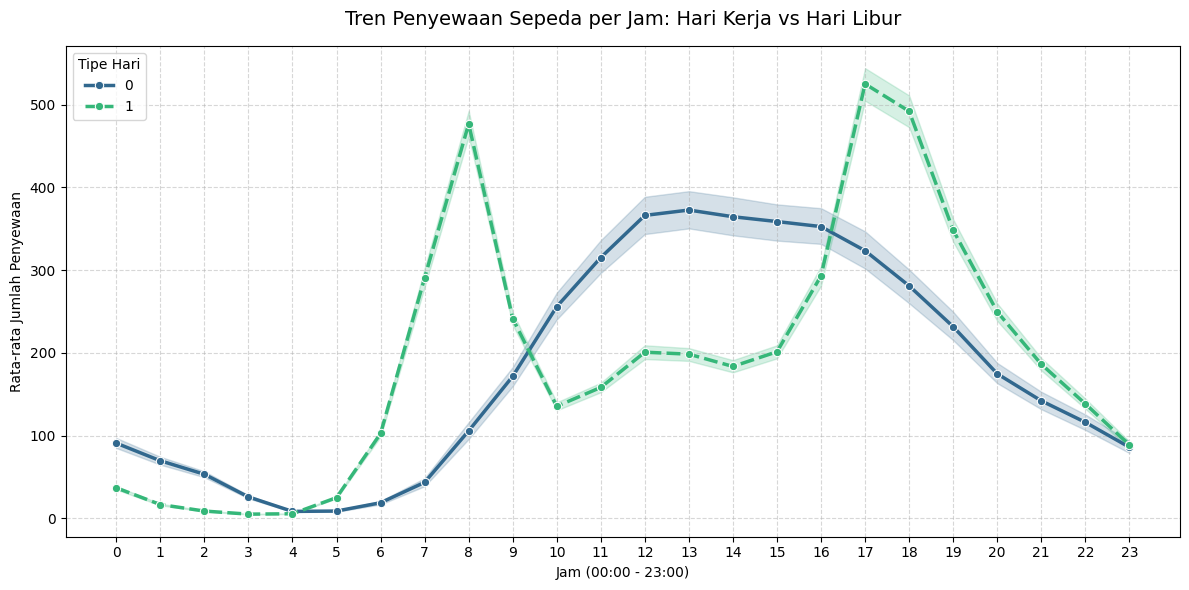

In [ ]:
plot_df = hour_df.copy()
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=plot_df,
    x='hour',
    y='rental_total',
    hue='workingday',
    style='workingday',
    palette='viridis',
    marker='o',
    linewidth=2.5
)

plt.title("Tren Penyewaan Sepeda per Jam: Hari Kerja vs Hari Libur", fontsize=14, pad=15)
plt.xlabel("Jam (00:00 - 23:00)")
plt.ylabel("Rata-rata Jumlah Penyewaan")
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.5)

plt.legend(title="Tipe Hari", loc='upper left')

plt.tight_layout()
plt.show()

**Insight:**
- Pada hari kerja memiliki dua puncak (bimodal) yaitu jam 08.00 dan jam 17.00. Menunjukkan bahwa sepeda adalah alat transportasi yang sangat efektif selama hari kerja. Sedangkan, pada hari libur memiliki satu puncak landai (unimodal). Penggunaan meningkat secara bertahap sejak pagi dan mencapai puncaknya pada siang hari dari pukul 12:00 hingga 15:00. Ini menunjukkan bahwa sepeda digunakan hanya untuk aktivitas rekreasi dan gaya hidup pada hari libur.

### Pertanyaan 2:

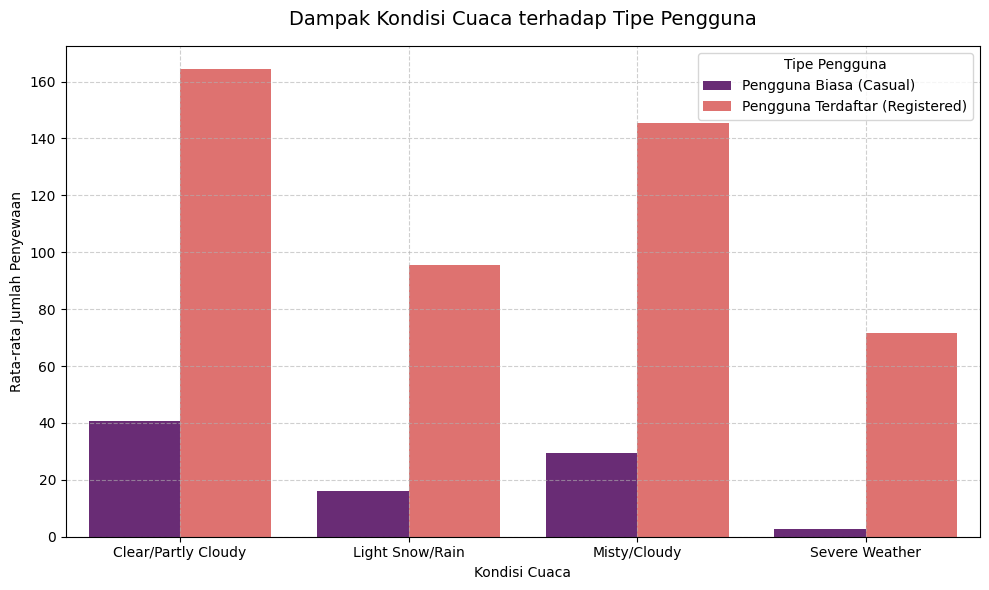

In [ ]:
weather_df_agg = hour_df.groupby('weathersit')[['casual', 'registered']].mean().reset_index()

weather_melted = weather_df_agg.melt(id_vars='weathersit', var_name='user_type', value_name='avg_rentals')

weather_melted['user_type'] = weather_melted['user_type'].replace({
    'casual': 'Pengguna Biasa (Casual)',
    'registered': 'Pengguna Terdaftar (Registered)'
})

plt.figure(figsize=(10, 6))
sns.barplot(
    x="weathersit",
    y="avg_rentals",
    hue="user_type",
    data=weather_melted,
    palette="magma"
)

plt.title("Dampak Kondisi Cuaca terhadap Tipe Pengguna", fontsize=14, pad=15)
plt.xlabel("Kondisi Cuaca")
plt.ylabel("Rata-rata Jumlah Penyewaan")
plt.legend(title="Tipe Pengguna")
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

**Insight:**
- Pengguna Terdaftar selalu jauh lebih banyak dibandingkan Pengguna Biasa di semua kondisi cuaca (1, 2, dan 3). Ini menunjukkan bahwa pelanggan tetap yang sangat bergantung pada layanan adalah tulang punggung utama bisnis ini.
- Sensivitas Cuaca Bervariasi:
Pengguna Biasa (Casual) Sangat sensitif terhadap cuaca. Terjadi penurunan drastis pada grafik saat berpindah dari cuaca cerah (1) ke cuaca buruk (3). Ini membuktikan bahwa bagi mereka, bersepeda adalah pilihan aktivitas rekreasi yang hanya dilakukan saat cuaca mendukung. Sedangkan Pengguna Terdaftar (Registered) menunjukkan ketahanan (resiliensi) yang lebih tinggi. Pengguna sepeda umum tidak mengalami penurunan jumlah yang signifikan meskipun cuaca memburuk. Ini menunjukkan bahwa bagi mereka, sepeda masih merupakan kebutuhan fungsional (transportasi wajib) meskipun cuaca tidak nyaman.

## Analisis Lanjutan (Opsional)

/tmp/ipykernel_5833/181669783.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


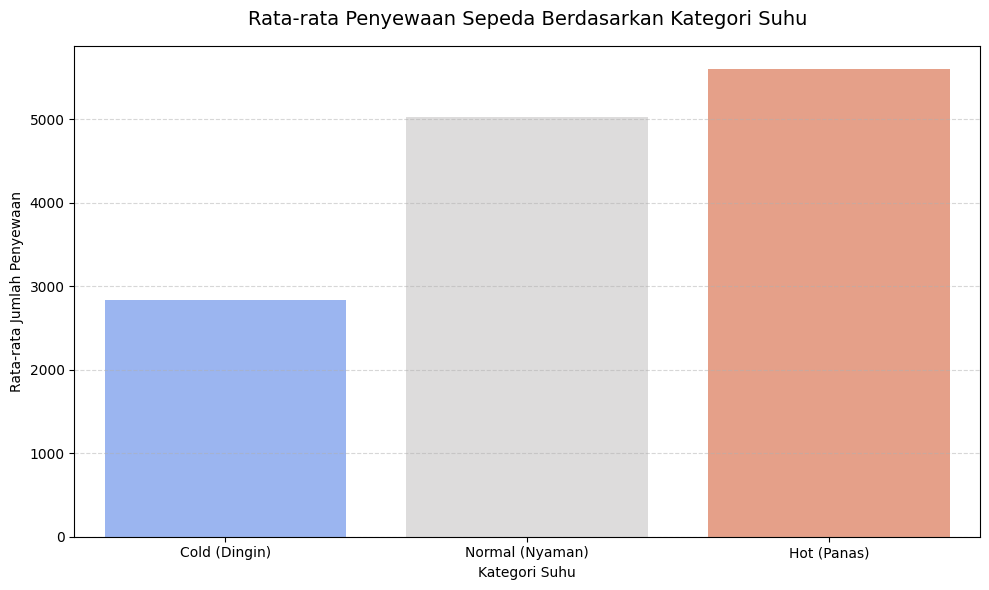

,Kategori Suhu,Rata-rata,Maksimum,Minimum,Jumlah Hari
0,Cold (Dingin),2833.316742,5992,431,221
1,Hot (Panas),5601.158192,8173,1115,177
2,Normal (Nyaman),5030.363363,8714,22,333


In [ ]:
def categorize_temp(temp):
    if temp < 15:
        return 'Cold (Dingin)'
    elif 15 <= temp <= 27:
        return 'Normal (Nyaman)'
    else:
        return 'Hot (Panas)'

day_df['temp_category'] = day_df['temp'].apply(categorize_temp)

temp_binning_analysis = day_df.groupby('temp_category').agg({
    'rental_total': ['mean', 'max', 'min', 'count']
}).reset_index()

temp_binning_analysis.columns = ['Kategori Suhu', 'Rata-rata', 'Maksimum', 'Minimum', 'Jumlah Hari']

plt.figure(figsize=(10, 6))
sns.barplot(
    x='Kategori Suhu',
    y='Rata-rata',
    data=temp_binning_analysis,
    order=['Cold (Dingin)', 'Normal (Nyaman)', 'Hot (Panas)'],
    palette='coolwarm'
)

plt.title('Rata-rata Penyewaan Sepeda Berdasarkan Kategori Suhu', fontsize=14, pad=15)
plt.xlabel('Kategori Suhu')
plt.ylabel('Rata-rata Jumlah Penyewaan')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

display(temp_binning_analysis)

## Conclusion

- Conclution pertanyaan 1: Terdapat perbedaan fungsi penggunaan antara hari kerja dan hari libur. Pada hari kerja, polanya bersifat bimodal dengan puncak di jam sibuk (08.00 dan 17.00) untuk komuter. Sedangkan pada hari libur, polanya bersifat unimodal dengan puncak di siang hari (12.00 - 15.00) untuk rekreasi.
- Conclution pertanyaan 2: Cuaca buruk berdampak drastis pada penurunan penyewa Casual karena motivasi penggunaannya bersifat rekreasi. Sebaliknya, Pengguna Terdaftar (Registered) jauh lebih stabil (resilient) karena menggunakan sepeda sebagai transportasi rutin (fungsional) meski cuaca kurang ideal.
- Conclution pertanyaan 3: Berdasarkan kategori suhu rata-rata penyewaan mencapai titik paling optimal pada kategori suhu Normal (15°C - 27°C). Sebaliknya, suhu Dingin (Cold) merupakan faktor penghambat utama yang menyebabkan penurunan jumlah penyewaan paling signifikan dibandingkan kategori suhu lainnya.

In [ ]:
import os

if not os.path.exists('dashboard'):
    os.makedirs('dashboard')

main_data_df = hour_df.copy()

def categorize_temp(temp):
    if temp < 15: return 'Cold (Dingin)'
    elif 15 <= temp <= 27: return 'Normal (Nyaman)'
    else: return 'Hot (Panas)'

main_data_df['temp_category'] = main_data_df['temp'].apply(categorize_temp)

main_data_df['workingday'] = main_data_df['workingday'].map({1: 'Hari Kerja', 0: 'Hari Libur'})

main_data_df.to_csv("dashboard/main_data.csv", index=False)